# **Classification Case: Credit Score**

## **0. Setup**

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn import set_config
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Credit Score.csv')
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,...,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780,10,...,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,...,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365,8,...,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,...,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard


In [3]:
print("This dataset contains (rows, columns):", df.shape)

df.info()
df.describe(include= 'all').transpose()

This dataset contains (rows, columns): (50000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Lo

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,50000,50000,0xc765,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,50000,12443,CUS_0x12cb,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,50000,8,January,6338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,45058,10056,Deepa Seetharamanm,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,50000,995,31,1488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,50000,12415,#F%$D@*&8,2805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,50000,16,_______,3481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,50000,15954,17816.75,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Inhand_Salary,42512.0,NaN,NaN,NaN,4203.216405,3183.003079,303.645417,1630.113333,3105.01,5974.963333,15204.633333
Num_Bank_Accounts,50000.0,NaN,NaN,NaN,17.08608,118.287242,-1.0,3.0,6.0,7.0,1798.0


In [4]:
num_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
            'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
            'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
            'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
            'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
cat_cols = ['Occupation', 'Type_of_Loan', 'Payment_Behaviour']
ord_cols = ['Credit_Mix']
bin_cols = ['Payment_of_Min_Amount']

print("Numeric cols :", num_cols)
print("Categorical cols :", cat_cols)
print("Ordinal cols :", ord_cols)
print("Binary cols:", bin_cols)

Numeric cols : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
Categorical cols : ['Occupation', 'Type_of_Loan', 'Payment_Behaviour']
Ordinal cols : ['Credit_Mix']
Binary cols: ['Payment_of_Min_Amount']


### *a. Data Preprocessing*

In [5]:
df = df.drop(columns= ['ID', 'Customer_ID', 'Month', 'Name', 'SSN'])
print(df.columns)

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')


In [6]:
cols_cast = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
             'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_cast:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.-]', '', regex= True), errors= "coerce")

df[cols_cast].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      50000 non-null  int64  
 1   Annual_Income            50000 non-null  float64
 2   Num_of_Loan              50000 non-null  int64  
 3   Num_of_Delayed_Payment   46398 non-null  float64
 4   Changed_Credit_Limit     48972 non-null  float64
 5   Outstanding_Debt         50000 non-null  float64
 6   Amount_invested_monthly  47773 non-null  float64
 7   Monthly_Balance          49389 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 3.1 MB


In [7]:
df['Credit_History_Age'] = df['Credit_History_Age'].astype(str).str.findall(r'\d+').apply(
    lambda x: (int(x[0]) * 12 + int(x[1])) if isinstance(x, list) and len(x) == 2 else np.nan
)
df[['Age', 'Credit_History_Age']].head(10)

,Age,Credit_History_Age
0,49,218.0
1,40,NaN
2,38,50.0
3,24,NaN
4,39,181.0
5,34,374.0
6,32,189.0
7,36,183.0
8,25,216.0
9,52,NaN


In [8]:
df['Type_of_Loan_Count'] = df['Type_of_Loan'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('Not Specified')
df['Type_of_Loan'] = df['Type_of_Loan'].apply(lambda x: str(x).split(',')[0].strip())

df[['Type_of_Loan', 'Type_of_Loan_Count']].head(10)

,Type_of_Loan,Type_of_Loan_Count
0,Personal Loan,2
1,Payday Loan,9
2,Auto Loan,9
3,Home Equity Loan,3
4,Payday Loan,3
5,Student Loan,4
6,Debt Consolidation Loan,7
7,Payday Loan,5
8,Personal Loan,7
9,Payday Loan,4


In [9]:
credit_mix_mapping = {'Bad': 0, 'Standard': 1, 'Good': 2, '_': 1}
payment_biner_mapping = {'Yes': 1, 'No': 0, 'NM': 0}

df["Credit_Mix"] = df["Credit_Mix"].map(credit_mix_mapping)
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].map(payment_biner_mapping).astype(int)
print(df["Credit_Mix"].value_counts())
print(df["Payment_of_Min_Amount"].value_counts())

Credit_Mix
1    28265
2    12315
0     9420
Name: count, dtype: int64
Payment_of_Min_Amount
1    26061
0    23939
Name: count, dtype: int64


### *b. Data Cleansing*

In [10]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 80)]
df = df[(df['Num_of_Loan'] >= 0) & (df['Num_of_Loan'] <= 50)]
df = df[df['Outstanding_Debt'] >= 0]
df = df[df['Num_of_Delayed_Payment'] <= 60]
df = df[df['Credit_History_Age'] <= (df['Age'] * 12)]
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')
df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Standard')

selected_columns = ['Age', 'Credit_History_Age', 'Num_of_Loan', 'Outstanding_Debt', 
                    'Num_of_Delayed_Payment', 'Occupation', 'Credit_Mix']
df[selected_columns].head(10)

,Age,Credit_History_Age,Num_of_Loan,Outstanding_Debt,Num_of_Delayed_Payment,Occupation,Credit_Mix
2,38,50.0,9,3075.29,19.0,Unknown,0
4,39,181.0,3,2192.93,17.0,Scientist,1
5,34,374.0,4,29.16,15.0,Teacher,1
6,32,189.0,7,2547.85,24.0,Teacher,0
7,36,183.0,5,1831.87,23.0,Lawyer,0
8,25,216.0,7,788.40,16.0,Entrepreneur,1
12,49,299.0,2,1408.37,8.0,Architect,2
14,37,105.0,5,281.84,7.0,Mechanic,1
15,29,186.0,5,2314.96,16.0,Manager,0
17,27,297.0,0,877.78,11.0,Architect,2


In [11]:
missing_df = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage (%)': (df.isna().sum() / len(df)) * 100
})

missing_df = missing_df[missing_df['Missing_Count'] > 0]
missing_df = missing_df.sort_values(by= 'Missing_Count', ascending= False)
missing_df

,Missing_Count,Missing_Percentage (%)
Monthly_Inhand_Salary,4906,14.955949
Amount_invested_monthly,1457,4.441667
Changed_Credit_Limit,695,2.118709
Num_Credit_Inquiries,667,2.033351
Monthly_Balance,384,1.170625


In [12]:
cols_dropna = ['Amount_invested_monthly', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Monthly_Balance']
df = df.dropna(subset= cols_dropna)

missing_df_now = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage (%)': df.isna().sum() / len(df) * 100
}).query('Missing_Count > 0').sort_values('Missing_Count', ascending=False)

missing_df_now

,Missing_Count,Missing_Percentage (%)
Monthly_Inhand_Salary,4444,14.962963


In [13]:
duplicate_count = df.duplicated().sum()
print("Total duplicates check:", duplicate_count)

Total duplicates check: 0


In [14]:
for col in cat_cols:
    if col in df.columns:
        print(f"\n{'─'*30}")
        print(f"  {col}")
        print(f"{'─'*30}")
        print(df[col].value_counts().head())


──────────────────────────────
  Occupation
──────────────────────────────
Occupation
Unknown      2062
Lawyer       2025
Developer    1900
Engineer     1897
Mechanic     1893
Name: count, dtype: int64

──────────────────────────────
  Type_of_Loan
──────────────────────────────
Type_of_Loan
Not Specified              6175
Credit-Builder Loan        3115
Personal Loan              3054
Payday Loan                2994
Debt Consolidation Loan    2940
Name: count, dtype: int64

──────────────────────────────
  Payment_Behaviour
──────────────────────────────
Payment_Behaviour
Low_spent_Small_value_payments      7416
High_spent_Medium_value_payments    5347
Low_spent_Medium_value_payments     4136
High_spent_Large_value_payments     3967
High_spent_Small_value_payments     3384
Name: count, dtype: int64


In [15]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', 'Unknown')
print(df['Payment_Behaviour'].value_counts())

Payment_Behaviour
Low_spent_Small_value_payments      7416
High_spent_Medium_value_payments    5347
Low_spent_Medium_value_payments     4136
High_spent_Large_value_payments     3967
High_spent_Small_value_payments     3384
Low_spent_Large_value_payments      3188
Unknown                             2262
Name: count, dtype: int64


In [16]:
check_outliers = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
                  'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Utilization_Ratio']

for col in check_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}, Outlier: {len(outliers)}")

Age, Outlier: 0
Annual_Income, Outlier: 856
Monthly_Inhand_Salary, Outlier: 555
Outstanding_Debt, Outlier: 1452
Total_EMI_per_month, Outlier: 2065
Amount_invested_monthly, Outlier: 3004
Monthly_Balance, Outlier: 2296
Credit_Utilization_Ratio, Outlier: 1


## **1. EDA (Exploratory Data Analysis)**

In [17]:
colors = ['#e74c3c', '#f39c12', '#2ecc71']

**a. *Target Variable Distribution***

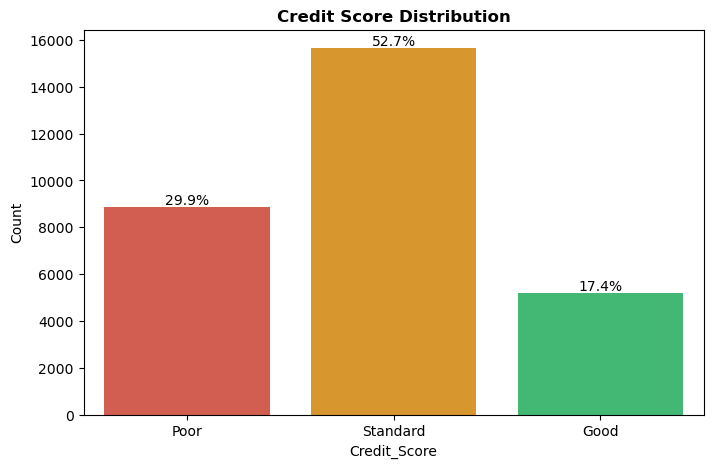

In [18]:
plt.figure(figsize= (8,5))
ax = sns.countplot(x= 'Credit_Score', data= df, palette= colors)
total = len(df)

for container in ax.containers:
    labels = [f"{(v.get_height() / total * 100):.1f}%" for v in container]
    ax.bar_label(container, labels=labels)

plt.title("Credit Score Distribution", fontsize= 12, fontweight= 'bold')
plt.xlabel('Credit_Score')
plt.ylabel('Count')
plt.show()

**b. *Univariate Analysis and Skewness***

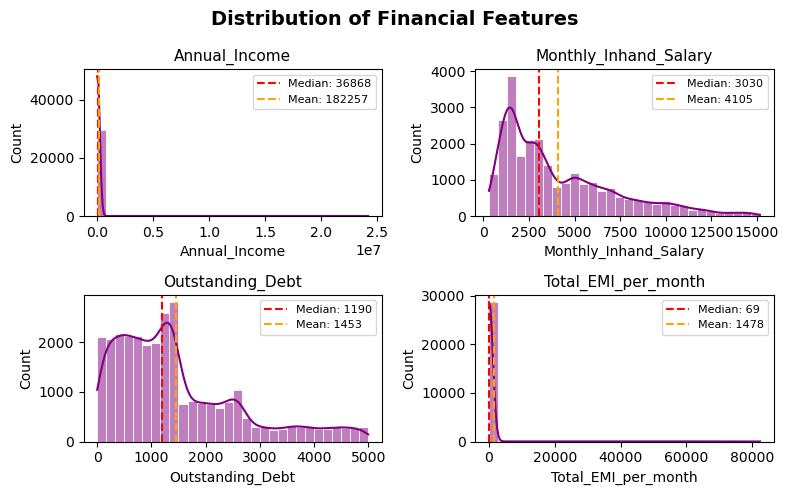

In [19]:
financial_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Total_EMI_per_month']
fig, axes = plt.subplots(2, 2, figsize=(8,5))

for ax, col in zip(axes.flatten(), financial_cols):
    sns.histplot(df[col].dropna(), bins= 30, ax= ax, color= 'purple', kde= True, edgecolor= 'white')
    ax.axvline(df[col].median(), color= 'red', linestyle= '--', label=f'Median: {df[col].median():.0f}')
    ax.axvline(df[col].mean(), color= 'orange', linestyle= '--', label=f'Mean: {df[col].mean():.0f}')
    
    ax.set_title(col, fontsize= 11)
    ax.legend(fontsize= 8)

plt.suptitle("Distribution of Financial Features", fontsize= 14, fontweight= 'bold')
plt.tight_layout()
plt.show()

**c. *Correlation Heatmap***

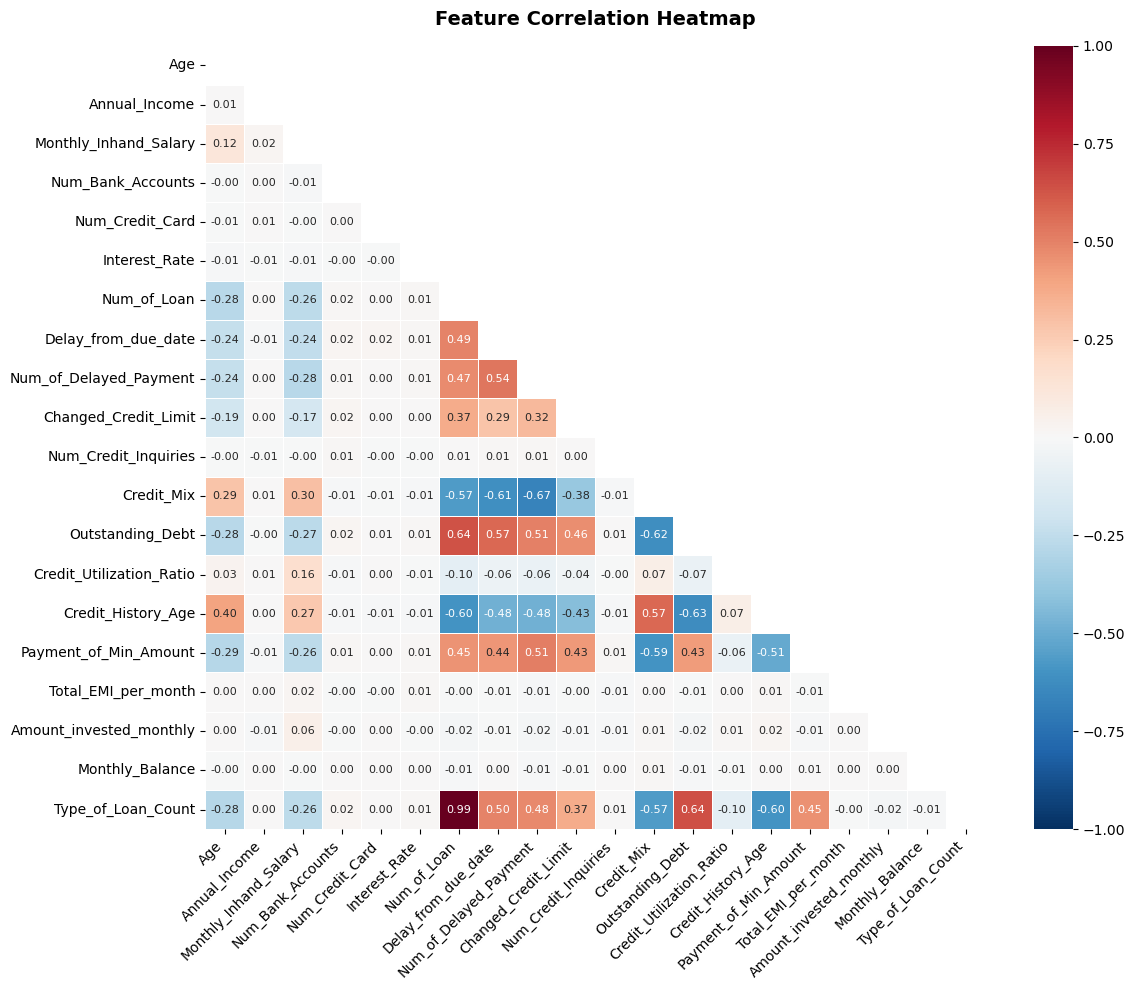

In [20]:
corr_cols = df.select_dtypes(include= ['float64', 'int64']).columns
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype= bool))
plt.figure(figsize= (12,10))
sns.heatmap(corr_matrix, mask= mask, annot= True, fmt= '.2f', cmap= 'RdBu_r',
            center= 0, vmin= -1, vmax= 1, linewidths= 0.5, annot_kws={"size": 8}
)
plt.title("Feature Correlation Heatmap", fontsize= 14, fontweight= 'bold', pad= 15)
plt.xticks(rotation= 45, ha= 'right')
plt.yticks(rotation= 0)
plt.tight_layout()
plt.show()

**d. *Bivariate Analysis (Outstanding_Debt vs Credit_Score)***

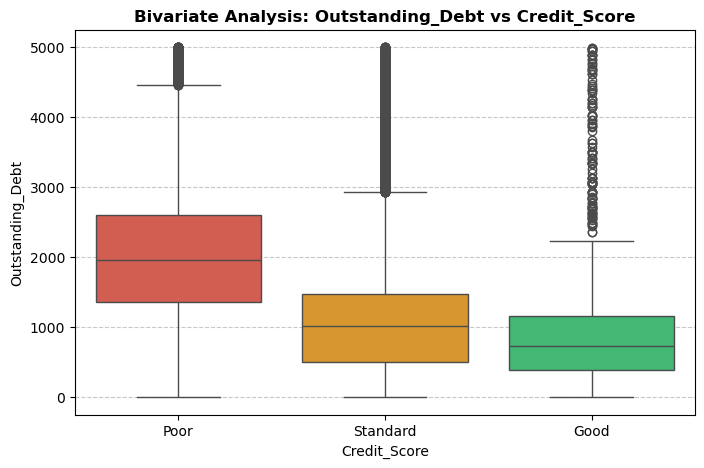

In [21]:
plt.figure(figsize= (8,5))
sns.boxplot(x= 'Credit_Score', y= 'Outstanding_Debt', data= df, palette= colors)
plt.title("Bivariate Analysis: Outstanding_Debt vs Credit_Score", fontweight= 'bold')
plt.xlabel('Credit_Score')
plt.ylabel('Outstanding_Debt')
plt.grid(axis= 'y', linestyle= '--', alpha=0.7)
plt.show()

**e. *Bivariate Analysis: Payment_Behaviour vs Credit_Score***

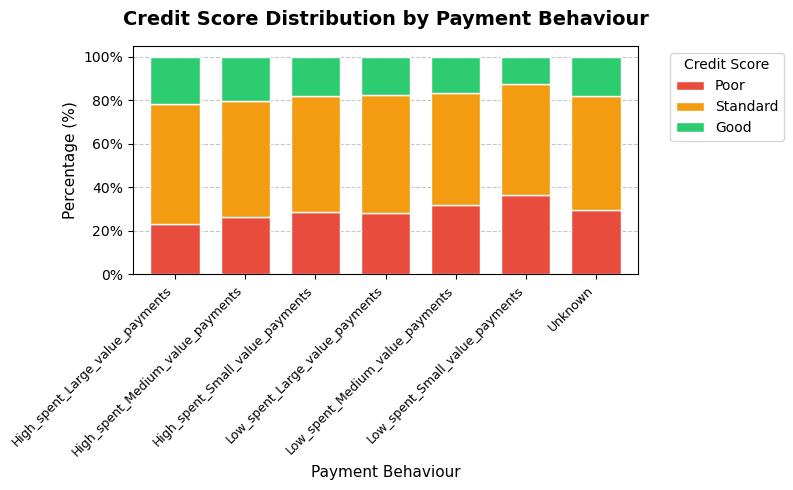

In [22]:
prop_df = (df.groupby('Payment_Behaviour')['Credit_Score'].value_counts(normalize= True).unstack() * 100)[['Poor', 'Standard', 'Good']]

fig, ax = plt.subplots(figsize=(8,5))
prop_df.plot(kind= 'bar', stacked= True, color = colors, edgecolor= 'white', width= 0.7,ax= ax)

ax.set_title('Credit Score Distribution by Payment Behaviour', 
             fontsize= 14, fontweight= 'bold', pad= 15)
ax.set_ylabel('Percentage (%)', fontsize= 11)
ax.set_xlabel('Payment Behaviour', fontsize= 11)
ax.set_xticklabels(ax.get_xticklabels(), rotation= 45, ha= 'right', fontsize= 9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(title= 'Credit Score', bbox_to_anchor= (1.05, 1), loc= 'upper left')
ax.grid(axis= 'y', linestyle= '--', alpha= 0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Statistical Tesing**

In [23]:
debt_poor = df[df['Credit_Score'] == 'Poor']['Outstanding_Debt']
debt_standard = df[df['Credit_Score'] == 'Standard']['Outstanding_Debt']
debt_good = df[df['Credit_Score'] == 'Good']['Outstanding_Debt']
h_stat, p_value = stats.kruskal(debt_poor, debt_standard, debt_good)

print(f"H-statistic : {h_stat:.4f}")
print(f"P-value : {p_value:.4e}")

H-statistic : 5830.7014
P-value : 0.0000e+00


In [24]:
contingency_table = pd.crosstab(df['Payment_Behaviour'], df['Credit_Score'])
print(contingency_table)
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic : {chi2_stat:.4f}")
print(f"P-value : {p_val:.4e}")
print(f"Degrees of Freedom : {dof}")

Credit_Score                      Good  Poor  Standard
Payment_Behaviour                                     
High_spent_Large_value_payments    866   914      2187
High_spent_Medium_value_payments  1090  1397      2860
High_spent_Small_value_payments    618   970      1796
Low_spent_Large_value_payments     556   900      1732
Low_spent_Medium_value_payments    698  1323      2115
Low_spent_Small_value_payments     939  2694      3783
Unknown                            410   671      1181

Chi-Square Statistic : 384.4345
P-value : 7.4520e-75
Degrees of Freedom : 12


## **2. Modeling**

In [25]:
# Update Columns
num_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
            'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
            'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
            'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
            'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 
            'Type_of_Loan_Count']

cat_cols = ['Occupation', 'Type_of_Loan', 'Payment_Behaviour']
ord_cols = ['Credit_Mix']
bin_cols = ['Payment_of_Min_Amount']

print("Numeric cols :", num_cols)
print("Categorical cols :", cat_cols)
print("Ordinal cols :", ord_cols)
print("Binary cols:", bin_cols)

Numeric cols : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Type_of_Loan_Count']
Categorical cols : ['Occupation', 'Type_of_Loan', 'Payment_Behaviour']
Ordinal cols : ['Credit_Mix']
Binary cols: ['Payment_of_Min_Amount']


In [26]:
# Split Data (0.8 ; 0.2)
X = df.drop(columns= ['Credit_Score'])
y = df['Credit_Score']

label = LabelEncoder()
y_enc = label.fit_transform(y)
print(f"Label Mapping: {dict(zip(label.classes_, label.transform(label.classes_)))}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size= 0.2, random_state= 42, stratify= y_enc
)

print(f"Total Rows: {len(df)}")
print(f"Training Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")

Label Mapping: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}

Total Rows: 29700
Training Set Shape: (23760, 23)
Test Set Shape: (5940, 23)


In [27]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown= 'ignore', drop= 'first'))
])

ord_bin_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'most_frequent'))
])

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('ord_bin', ord_bin_transformer, ord_cols + bin_cols)
    ],
    remainder= 'passthrough'
)

***Feature Engineering***

In [29]:
def create_features(df):
    df_copy = df.copy()
    if 'Annual_Income' in df_copy.columns and 'Monthly_Inhand_Salary' in df_copy.columns:
        df_copy['Income_vs_Monthly_Salary'] = df_copy['Annual_Income'] / (df_copy['Monthly_Inhand_Salary'] * 12 + 1)

    if 'Num_of_Loan' in df_copy.columns and 'Annual_Income' in df_copy.columns:
        df_copy['Debt_to_Income_Ratio'] = df_copy['Num_of_Loan'] / (df_copy['Annual_Income'] + 1)

    if 'Credit_Utilization_Ratio' in df_copy.columns and 'Interest_Rate' in df_copy.columns:
        df_copy['Credit_Risk_Interaction'] = df_copy['Credit_Utilization_Ratio'] * df_copy['Interest_Rate']
        
    return df_copy

feature_creator = FunctionTransformer(create_features)

In [30]:
pipelines = {
    'Random Forest': Pipeline([
        ('feature_creator', feature_creator),
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state= 42,
                                         n_estimators= 200,
                                         n_jobs= -1,
                                         class_weight= 'balanced'))
    ]),

    'XGBoost': Pipeline([
        ('feature_creator', feature_creator),
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(random_state= 42,
                                use_label_encoder= False,
                                eval_metric= 'mlogloss',
                                n_estimators= 200,
                                learning_rate= 0.1,
                                n_jobs= -1,
                                verbosity= 0))
    ]),

    'LightGBM': Pipeline([
        ('feature_creator', feature_creator),
        ('preprocessor', preprocessor),
        ('model', LGBMClassifier(random_state= 42,
                                 n_estimators= 200,
                                 learning_rate= 0.1,
                                 n_jobs= -1,
                                 verbose= -1))
    ])
}

***Hyperparameter Tuning***

In [32]:
param_grids = {
    'Random Forest': {
        'model__n_estimators': [200, 300],
        'model__max_depth': [10, 20, 30, None],
        'model__min_samples_leaf': [1, 2, 4],
        'model__min_samples_split': [2, 10],
        'model__max_features': ['sqrt', 'log2']
    },

    'XGBoost': {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [5, 7],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
        'model__gamma': [0, 0.1],
        'model__reg_alpha': [0, 0.01]
    },

    'LightGBM': {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves': [31, 40, 50],
        'model__max_depth': [7, 10],
        'model__min_child_samples': [20, 50],
        'model__subsample': [0.8, 1.0]
    }
}

In [33]:
tuned_models = {}
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

for name, pipe in pipelines.items():
    print(f"Tuning {name}...")
        
    search = RandomizedSearchCV(
        estimator= pipe,
        param_distributions= param_grids[name],
        n_iter= 50, 
        scoring= {'roc_auc': 'roc_auc_ovr', 'f1': 'f1_macro'},
        refit= 'roc_auc',
        cv= cv,
        random_state= 42,
        n_jobs= -1,
        verbose= 1,
        return_train_score= True
    )
    
    search.fit(X_train, y_train)
    
    print(f"Best Params for {name}: {search.best_params_}")
    print(f"Best ROC-AUC for {name}: {search.best_score_:.4f}\n")
    tuned_models[name] = search.best_estimator_

Tuning Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params for Random Forest: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}
Best ROC-AUC for Random Forest: 0.8839

Tuning XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params for XGBoost: {'model__subsample': 0.8, 'model__reg_alpha': 0.01, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}
Best ROC-AUC for XGBoost: 0.8790

Tuning LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params for LightGBM: {'model__subsample': 0.8, 'model__num_leaves': 50, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': 10, 'model__learning_rate': 0.1}
Best ROC-AUC for LightGBM: 0.8747



## **3. Evaluation**

In [34]:
def evaluate(name, model, X_test, y_test_enc):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test_enc, y_pred)
    f1_macro = f1_score(y_test_enc, y_pred, average= 'macro')
    auc = roc_auc_score(y_test_enc, y_pred_proba, multi_class= 'ovr')

    print(f"Evaluation: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"ROC-AUC: {auc:.4f}")
    
    print("\nClassification Report:\n", classification_report(y_test_enc, y_pred, target_names= label.classes_))
    return {'Accuracy': accuracy, 'F1 Macro': f1_macro, 'ROC-AUC': auc}

In [35]:
results = {}
for name, model in tuned_models.items():
    results[name] = evaluate(name, model, X_test, y_test)

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by= 'ROC-AUC', ascending= False))

Evaluation: Random Forest
Accuracy: 0.7547
F1 Macro: 0.7330
ROC-AUC: 0.8905

Classification Report:
               precision    recall  f1-score   support

        Good       0.67      0.64      0.65      1035
        Poor       0.79      0.74      0.77      1774
    Standard       0.76      0.80      0.78      3131

    accuracy                           0.75      5940
   macro avg       0.74      0.73      0.73      5940
weighted avg       0.75      0.75      0.75      5940

Evaluation: XGBoost
Accuracy: 0.7468
F1 Macro: 0.7256
ROC-AUC: 0.8860

Classification Report:
               precision    recall  f1-score   support

        Good       0.66      0.63      0.65      1035
        Poor       0.78      0.73      0.75      1774
    Standard       0.76      0.79      0.77      3131

    accuracy                           0.75      5940
   macro avg       0.73      0.72      0.73      5940
weighted avg       0.75      0.75      0.75      5940

Evaluation: LightGBM
Accuracy: 0.7444
F1 M

,Accuracy,F1 Macro,ROC-AUC
Random Forest,0.754714,0.733018,0.890459
XGBoost,0.746801,0.725583,0.885992
LightGBM,0.744444,0.723581,0.881661


***Confusion Matrix Random Forest***

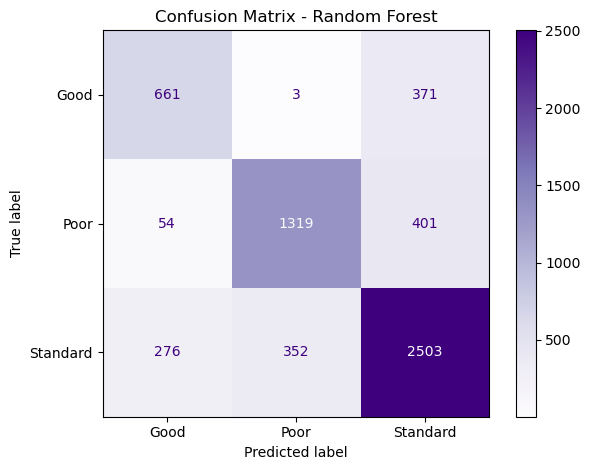

In [36]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model_obj = tuned_models[best_model_name]
y_pred_best = best_model_obj.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels= label.classes_, cmap= 'Purples')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## **4. Feature Importance**

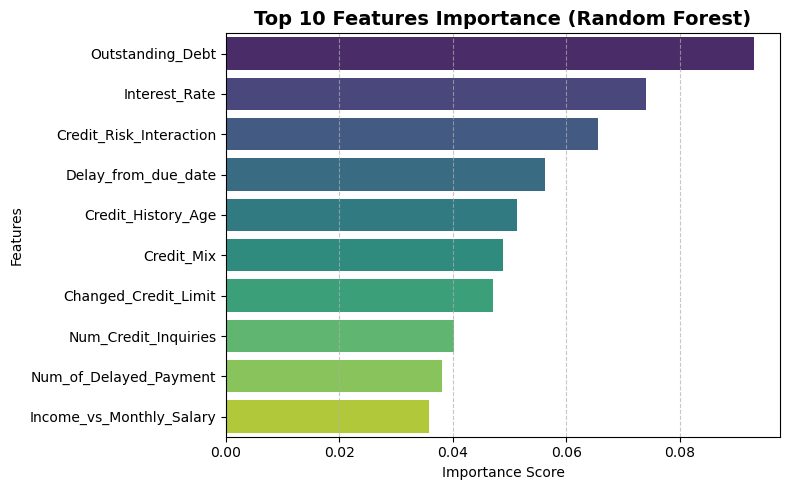

In [37]:
fi_pipeline = tuned_models[best_model_name]
model_step = fi_pipeline.named_steps['model']
feature_names = (fi_pipeline.named_steps['preprocessor'].get_feature_names_out())
feature_names = [re.sub(r'^(num|cat|ord_bin|remainder)__', '', f) for f in feature_names]

importances = pd.Series(model_step.feature_importances_, index=feature_names)
top10 = importances.nlargest(10).sort_values(ascending= False)

plt.figure(figsize= (8, 5))
sns.barplot(x= top10.values, y= top10.index, palette= 'viridis')
plt.title(f"Top 10 Features Importance ({best_model_name})", fontsize= 14, fontweight= 'bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis= 'x', linestyle= '--', alpha= 0.7)
plt.tight_layout()
plt.show()